<a href="https://colab.research.google.com/github/DarshanBothra/Coding-Assignment-SBILab/blob/main/Coding_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# import dependencies

import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.datasets import fetch_openml # to fetch mnist dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.exceptions import ConvergenceWarning

# supress convergence warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [6]:
# Download MNIST Dataset
print("Downloading MNIST Dataset... ")
mnist=fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Dataset Downloaded!")

X, y = mnist.data, mnist.target

# Normalize pixel values from 0 to 1
X = X/255.0

# Train-Test Split (Training: 80%, Testing: 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=51)




Dataset Downloaded!


Visualizing Samples


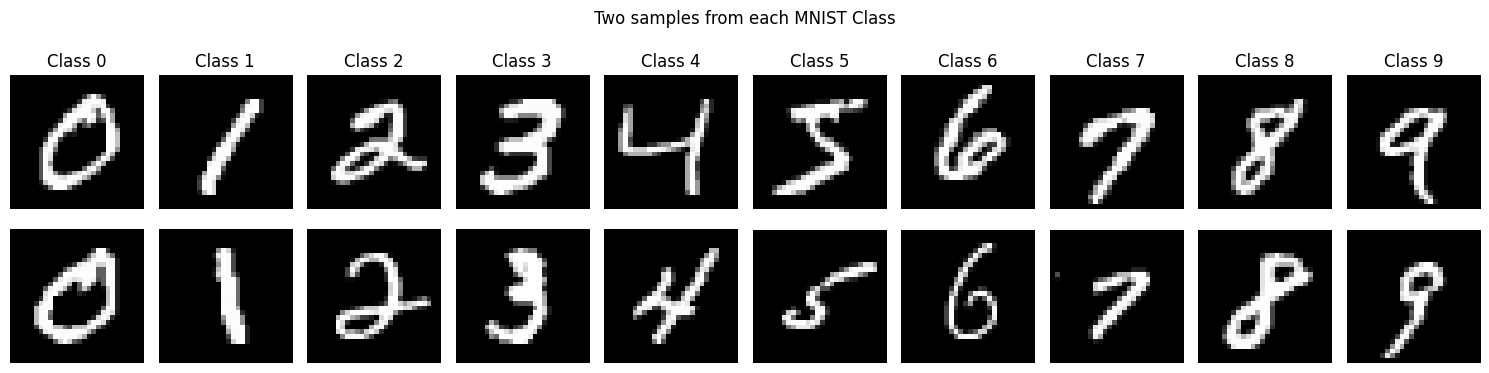

In [7]:
# Visualizing Samples
print("Visualizing Samples")
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
classes = np.unique(y)

for i, cls in enumerate(classes):
  idxs = np.where(y==cls)[0][:2] # First two samples from each class
  for j, idx in enumerate(idxs):
    img = X[idx].reshape(28, 28)
    axes[j, i].imshow(img, cmap='gray')
    axes[j, i].axis('off')
    if j == 0:
      axes[j, i].set_title(f"Class {cls}")
plt.suptitle("Two samples from each MNIST Class")
plt.tight_layout()
plt.show()

In [8]:
# Using Logistic Regression to Perform One VS One Classification
log_reg = LogisticRegression(solver="saga", max_iter = 50, random_state=51, n_jobs=-1)
print("Training One vs One Classifier")
ovo_clf = OneVsOneClassifier(log_reg, n_jobs=-1)
ovo_clf.fit(X_train, y_train)
ovo_preds = ovo_clf.predict(X_test)
ovo_accuracy = accuracy_score(y_test, ovo_preds) # Correct Predictions/Total Test Samples
print(f"One vs One Overall Accuracy: {ovo_accuracy*100:.4f}%\n")


Training One vs One Classifier
One vs One Overall Accuracy: 93.6143%



In [9]:
print("Training One vs Rest Classifier")
ovr_clf = OneVsRestClassifier(log_reg, n_jobs=-1)
ovr_clf.fit(X_train, y_train)
ovr_preds = ovr_clf.predict(X_test)
ovr_accuracy = accuracy_score(y_test, ovr_preds)
print(f"One vs Rest Overall Accuracy: {ovr_accuracy*100:.4f}%\n")

Training One vs Rest Classifier
One vs Rest Overall Accuracy: 91.2143%



In [10]:
pca = PCA(n_components=2)
pca.fit(X_train)
explained_variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"First two principal components retain {explained_variance:.4f}% of the variance.\n")

First two principal components retain 16.9083% of the variance.



In [11]:
# Best of two approaches is decided using Accuracy of both methods.

best_preds = ovo_preds
if ovo_accuracy < ovr_accuracy:
  best_preds = ovr_preds
  print(f"One vs Rest Classifier is better approach with accuracy: {ovr_accuracy*100:.4f}")
else:
  print(f"One vs One Classifier is better approach with accuracy: {ovo_accuracy*100:.4f}")

print("\nDetailed Classification Report: ")
print(classification_report(y_test, best_preds))

print("Class wise accuracy report: ")
cm = confusion_matrix(y_test, best_preds)
total_samples = np.sum(cm)
print(cm)
exit()
for i, cls in enumerate(classes):
  tp = cm[i, i] # true positives
  fp = np.sum(cm[:, i]) - tp # false positives = total predicted class - true positives
  fn = np.sum(cm[i, :]) - tp # false negatives = total true class - true positives
  tn = total_samples - tp - fp - fn # true negative

  class_acc = (tp + tn) / total_samples # (true positive + true negative)/total samples in class
  print(f"Class {cls}: {class_acc:.4f}")


One vs One Classifier is better approach with accuracy: 93.6143

Detailed Classification Report: 
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1349
           1       0.96      0.99      0.97      1545
           2       0.92      0.92      0.92      1396
           3       0.93      0.90      0.91      1463
           4       0.93      0.96      0.94      1363
           5       0.90      0.89      0.89      1299
           6       0.96      0.97      0.96      1385
           7       0.94      0.94      0.94      1507
           8       0.93      0.92      0.92      1322
           9       0.92      0.90      0.91      1371

    accuracy                           0.94     14000
   macro avg       0.94      0.94      0.94     14000
weighted avg       0.94      0.94      0.94     14000

Class wise accuracy report: 
[[1315    0    6    4    1   10    7    0    5    1]
 [   0 1525    5    5    2    1    1    3    3    0]
 [   2  